In [ ]:
!pip install pennylane --upgrade
!pip install qutip.qip
!pip install qutip
!pip install -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.0/130.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 22.4 MB/s eta 0:00:00
ERROR: You must give at least one requirement to install (see "pip help install")


In [ ]:
import numpy as np
import pennylane as qml
from pennylane import numpy as np
from qutip import Qobj, tensor, identity, qeye, ket2dm,ptrace
import qutip as qt
from scipy.linalg import expm, sinm, cosm
from qutip_qip.operations import *
from qutip import Qobj, sigmax, sigmay, sigmaz , tensor, qeye,ptrace
import matplotlib.pyplot as plt

In [ ]:
class QuantumCircuit:
    def __init__(self, num_qubits=2):
        #entrada de dados
        self.num_qubits = num_qubits
        self.dev = qml.device("default.mixed", wires=self.num_qubits,shots=shot)
        self._phi_inicial =qml.QNode(self.__phi_inicial,self.dev)
        self._phi_final =qml.QNode(self.__phi_final,self.dev)
        self._caixa_SWAP =qml.QNode(self.__caixa_SWAP,self.dev)
        self._phi_entagled =qml.QNode(self.__phi_entagled,self.dev)

    def u_minus1(self,x):
        # Calculate the components
        term1 = 1 * np.sqrt(1 - x) * qeye(2)
        term2 = (1j * np.sqrt(x)) * qt.sigmay()
        u_minus = term1 - term2
        return np.array((u_minus).full())

    def u_plus1(self,x):
        # Calculate the components
        term1 = 1 * np.sqrt(1 - x) * qeye(2)
        term2 = (1j * np.sqrt(x)) * qt.sigmay()
        u_minus = term1 + term2
        return np.array((u_minus).full())

    def __phi_entagled(self,theta_A,theta_B,x=0.5):
        qml.RX(theta_A, wires=0)
        qml.RX(theta_B, wires=self.num_qubits-1)
        #caixa termalizado
        for i in range(1,int(self.num_qubits/2)):
          qml.CNOT(wires=[0, i])
          qml.CNOT(wires=[self.num_qubits-1,self.num_qubits-(i+1) ])
        #caixa correlação
        for i in range(1,int(self.num_qubits/2)):
          qml.CNOT(wires=[i,self.num_qubits-(i+1)])
          qml.ControlledQubitUnitary(self.u_minus1(x), control_wires=[self.num_qubits-(i+1)], wires=[i])
          qml.CNOT(wires=[i,self.num_qubits-(i+1)])
        #conectar estados termalizados
        for i in range(1,int(self.num_qubits)-1):
          qml.CNOT(wires=[i,(i+1)])
          qml.ControlledQubitUnitary(self.u_minus1(x), control_wires=[(i+1)], wires=[i])
          qml.CNOT(wires=[i,(i+1)])
        return qml.state()

    def __phi_inicial(self,theta_A, theta_B,x=0.5):
        qml.RX(theta_A, wires=0)
        qml.RX(theta_B, wires=self.num_qubits-1)
        #caixa termalizado
        for i in range(1,int(self.num_qubits/2)):
          qml.CNOT(wires=[0, i])
          qml.CNOT(wires=[self.num_qubits-1,self.num_qubits-(i+1) ])
        #caixa correlação
        for i in range(1,int(self.num_qubits/2)):
          for j in range(1,int(self.num_qubits/2)):
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
            qml.ControlledQubitUnitary(self.u_minus1(x), control_wires=[self.num_qubits-(j+1)], wires=[i])
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
        return qml.state()

    def __phi_final(self,theta_A,theta_B,x=0.5):
        qml.RX(theta_A, wires=0)
        qml.RX(theta_B, wires=self.num_qubits-1)
        #caixa termalizado
        for i in range(1,int(self.num_qubits/2)):
          qml.CNOT(wires=[0, i])
          qml.CNOT(wires=[self.num_qubits-1,self.num_qubits-(i+1) ])
        #caixa de correlação
        for i in range(1,int(self.num_qubits/2)):
          for j in range(1,int(self.num_qubits/2)):
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
            qml.ControlledQubitUnitary(self.u_minus1(x), control_wires=[self.num_qubits-(j+1)], wires=[i])
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
        #caixa SWAP
        for i in range(1,int(self.num_qubits/2)):
          for j in range(1,int(self.num_qubits/2)):
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
            qml.ControlledQubitUnitary(self.u_plus1(x), control_wires=[self.num_qubits-(j+1)], wires=[i])
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
        return qml.state()

    def __caixa_SWAP(self,x,rho):
      #gerando uma lista com os fios
      wires_list=[]
      for i in range(self.num_qubits):
        wires_list.append(i)
      qml.QubitDensityMatrix(rho, wires=wires_list)
      #caixa swap
      for i in range(self.num_qubits):
        qml.U3(x[i+0],x[i+1],x[i+2], wires=i)
      return qml.state()

    def hamiltoniana(self,eb,ea=1):
      #gerando a matriz identidade para gerar os circuitos
      resultfi=Qobj(qeye(2**(self.num_qubits-2)),dims=(cnot(self.num_qubits-2,0,1).dims))
      inteiro=int((self.num_qubits)/2)
      #gerando o hamiltoniano para Num Qubits
      for i in range(1,self.num_qubits-1):
        result1=Qobj(1)
        result2=Qobj(1)
        for j in range(1,self.num_qubits-1):
          if i==j and i<inteiro:
            result1=tensor(result1,-ea*qt.sigmaz()/2)
            result2=tensor(result2,qeye(2))
          elif i==j and i>=inteiro:
            result2=tensor(result2,-eb*qt.sigmaz()/2)
            result1=tensor(result1,qeye(2))
          else:
            result1=tensor(result1,qeye(2))
            result2=tensor(result2,qeye(2))
        resultfi=resultfi+Qobj(result1+result2,dims=cnot(self.num_qubits-2,0,1).dims)
      return resultfi
    #truque para gerar a biblioteca do penny lane com POO
    def phi_inicial(self,theta_A, theta_B,x=0.5):
      return self._phi_inicial(theta_A, theta_B,x)

    def phi_entagled(self,theta_A, theta_B,x=0.5):
      return self._phi_entagled(theta_A, theta_B,x)

    def draw(self):#resposta temporaria
      qml.draw_mpl(self.__phi_inicial)(1,1,0.5)
      return

    def caixa_SWAP(self,x,rho):
      return self._caixa_SWAP(x,rho)

    def phi_final(self,theta_A,theta_B,x=0.5):
      return self._phi_final(theta_A,theta_B,x)


class QuantumOptimization:
    dev=None
    def __init__(self,num_qubits=2,epsilon=0.05,eb=0.5):
        self.num_qubits = num_qubits
        self.epsilon=epsilon
        self.eb=eb
        self.trace=np.linspace(1,num_qubits-2,num_qubits-2,dtype=int)
        self.quantum_circuit = QuantumCircuit(self.num_qubits)
        #self.dev = qml.device("default.mixed", wires=self.num_qubits)
        #self.circuit = qml.QNode(self.__circuit, self.dev)

    def loss1(self, rho0, rhof, H):#loss baseado no trabalho
        return np.real(((qt.ptrace(rhof,self.trace) - qt.ptrace(rho0,self.trace)) * H).tr())

    def thetas_c(self,bb=2,ea=1,ba=1):
    #parametro de correlação
      #parametros do sistema
      bb=bb*ba
      #hamiltoniana do sitema
      sz=np.array([[1, 0], [0, -1]])

      H_A=-0.5*ea*sz
      H_B=-0.5*self.eb*sz

      # Função partição
      Za = np.trace(expm(-ba * H_A))

      Zb = np.trace(expm(-bb * H_B))
      #operador densidade

      p_a=np.exp(-ba*ea/2)/Za
      p_b=np.exp(-bb*self.eb/2)/Zb
      #coeficiente

      a=1/(Za*Zb)**1.5

      pp=0.5*(p_a+p_b+np.sqrt((p_b-p_a)**2+4*a**2))

      pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))

      x=((p_b-p_a)/(pp-pm)+1)*0.5
      #angulo para rotação x
      theta_a=2*np.arccos(np.sqrt(pp))
      theta_b=2*np.arccos(np.sqrt(pm))

      return theta_a,theta_b,x

    def loss_function(self, params):
        eb = self.eb
        A,B,x=self.thetas_c()
        rho = self.quantum_circuit.phi_entagled(A,B,x)
        rho=rho@np.conjugate(rho).T
        #print(rho)
        #print(self.circuit(params, rho))
        state = qt.Qobj(self.quantum_circuit.caixa_SWAP(params, rho), dims=cnot(self.num_qubits, 0, 1).dims)
        rho0 =  qt.Qobj(rho, dims=cnot(self.num_qubits, 0, 1).dims)
        rhof = state * state.dag()
        H = self.quantum_circuit.hamiltoniana(eb)

        return self.loss1(rho0, rhof, H)

    def parameter_shift_gradient(self, params, j):
        # metod do gradiente
        epsilon = self.epsilon
        shifted_params_plus = params.copy()
        shifted_params_plus[j] += epsilon

        shifted_params_minus = params.copy()
        shifted_params_minus[j] -= epsilon

        gradient = (
            self.loss_function(shifted_params_plus)
            - self.loss_function(shifted_params_minus)
        ) / (2 * epsilon)
        return gradient


    def stochastic_gradient_descent(self, params, learning_rate, num_epochs):
        epoch = 0
        loss = 0
        loss_vec = []
        epochs_vec = []
        #otimizando parametros
        while epoch < num_epochs:

            for j in range(len(params)):
                gradient = self.parameter_shift_gradient(params, j)
                params[j] -= learning_rate * np.real(gradient)

            loss = self.loss_function(params)
            loss_vec.append(loss)
            epochs_vec.append(epoch)
            print(f"Epoch {epoch+1}, Loss: {np.real(loss)}")
            epoch += 1
        return params, loss_vec, epochs_vec

class Plots:
  def __init__(self):
    pass
  def plotar(self,x,y,labelx,labely):
    plt.plot(x,y)
    plt.ylabel(labely)
    plt.xlabel(labelx)
    plt.grid(True)
    plt.show()


In [ ]:
num_qubits=6
Quan61=QuantumCircuit(num_qubits)
ebs=np.linspace(0,1,101)

for eb in ebs:
  Quan6=QuantumOptimization(num_qubits,0.001,eb)
  theta_a,theta_b,x=Quan6.thetas_c()
  print(theta_a,theta_b,x)

print(Quan6.stochastic_gradient_descent(np.random.rand(3*num_qubits),0.5,50))

Epoch 1, Loss: -0.047789967804979794
Epoch 2, Loss: -0.05376890698126224
Epoch 3, Loss: -0.06037654817949367
Epoch 4, Loss: -0.06765324262545147
Epoch 5, Loss: -0.07563799996365572
Epoch 6, Loss: -0.08436864383583531
Epoch 7, Loss: -0.0938825897836012
Epoch 8, Loss: -0.10421848253461774
Epoch 9, Loss: -0.11541893591489605
Epoch 10, Loss: -0.12753459484864416
Epoch 11, Loss: -0.14062967547444316
Epoch 12, Loss: -0.15478902818780482
Epoch 13, Loss: -0.17012660353833953
Epoch 14, Loss: -0.186794978519097
Epoch 15, Loss: -0.20499531809782678
Epoch 16, Loss: -0.22498680124751935
Epoch 17, Loss: -0.24709413093631794
Epoch 18, Loss: -0.27171127890353297
Epoch 19, Loss: -0.299299111491766
Epoch 20, Loss: -0.33037405821274346
Epoch 21, Loss: -0.365484625449755
Epoch 22, Loss: -0.4051724940131982
Epoch 23, Loss: -0.4499154298872097
Epoch 24, Loss: -0.5000506880759521
Epoch 25, Loss: -0.5556806624864086
Epoch 26, Loss: -0.6165682002588917
Epoch 27, Loss: -0.6820381095594628
Epoch 28, Loss: -0.750

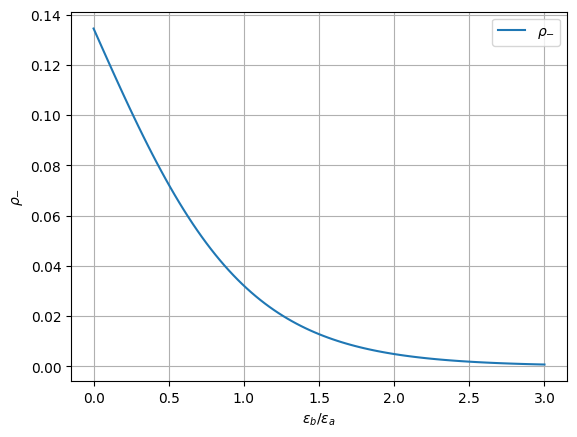

In [ ]:
def pminus1(e):
  ea=1
  ba=1
  bb=2*ba
  eb=e*ea
  #hamiltoniana do sitema
  H_A=-0.5*ea*qt.sigmaz()
  H_B=-0.5*eb*qt.sigmaz()
  #Função partição
  Za=((-ba*H_A).expm()).tr()
  Zb=((-bb*H_B).expm()).tr()
  #operador densidade
  p_a=np.exp(-ba*ea/2)/Za
  p_b=np.exp(-bb*eb/2)/Zb
  #parametro de correlação
  a=1/(Za*Zb)
  pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))
  return pm
#calculo
e=np.linspace(0,3,101)
pm=[]
pp=[]
alphs=[]
p=[]
for i in e:
  pp.append(pminus1(i))
#plot
#plt.plot(e,pm,label='$\\rho_{-}$')
plt.plot(e,pp,label='$\\rho_{-}$')
#plt.plot(e,alphs,label='$\\rho_{--}$')
plt.xlabel('$\\epsilon_{b}/\\epsilon_{a}$')
plt.ylabel('$\\rho_{-}$')
#plt.ylim(-0.02,0.02)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
num_qubits=4
Quan61=QuantumCircuit(num_qubits)
Quan6=QuantumOptimization(num_qubits,0.001)